In [1]:
# | include: false
# install dependencies for the code in this document (add packages here if importing something new)
!pip install --quiet matplotlib pyvista numpy


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# | include: false

# enforcing inline vector graphics
%config InlineBackend.figure_format = 'svg'

# trigger font manager cache rebuild
from matplotlib import figure

figure.Figure()

# AGH colours + colour-blind-safe linestyles + font sizes
import matplotlib
from cycler import cycler

matplotlib.rcParams.update(
    {
        "axes.prop_cycle": cycler(
            color=("#A71930", "#00693C", "#1E1E1E")
        )
        + cycler(linestyle=("-", "--", ":")),
        "lines.linewidth": 1.5,
        "lines.markersize": 3,
        "axes.grid": False,
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.figsize": (5, 3.5),
        "legend.handlelength": 1.0,
    }
)

In [3]:
# | include: false
with open("refs.bib", "w", encoding="utf8") as f:
    f.write(r"""
@inproceedings{vanRossum_1998,
  year         = {1998},
  author       = {van Rossum, Guido},
  title        = {Glue It All Together With {Python}},
  url          = {https://web.archive.org/web/19980614041513/http://www.objs.com/workshops/ws9801/papers/paper070.html},
  booktitle    = {OMG-DARPA-MCC Workshop on Compositional Software Architecture},
  address      = {Monterey, California, January 6-8, 1998}
}

@inproceedings{Dijkstra_1970,
  title        = {Structured programming},
  url          = {https://web.archive.org/web/20260421071308/http://homepages.cs.ncl.ac.uk/brian.randell/NATO/nato1969.PDF},
  author       = {Dijkstra, E. W.},
  booktitle    = {Software Engineering Techniques: Report on a conference sponsored by the NATO Science Committee},
  editor       = {J. N. Buxton and B. Randell},
  address      = {Rome, Italy, October 27-31, 1969},
  year         = {1970}
}

""")

\pagenumbering{roman}
\setcounter{page}{1}

\selectlanguage{english}
\addcontentsline{toc}{section}{\abstractname}
\begin{abstract}
  \noindent
  {\bf TL;DR} 
  \hspace*{\fill} {\bf research}: not automated $\leadsto$ not reproducible $\leadsto$ not science! \\
  \hspace*{\fill} {\bf development}: not automated $\leadsto$ not scalable $\leadsto$ not marketable\\
  
  This handbook aims to help students bridge the gap between code and thesis markup.
  We take it to the extreme: the thesis's only source file is a single \techword{Jupyter} notebook 
    containing both the narrative, and the integrated plotting and data-manipulation logic.
  This approach ensures that the entire thesis -- including graphics, in-text values, and tabulated numerical
    results -- can be reproduced from a single source file with one \verb=quarto render thesis.ipynb= command 
    (where \techword{Quarto} is the document preparation system embraced here).
  Besides keeping things simple, this workflow fosters key prerequisites for
    reproducible and auditable research, as well as for scalable and productisable developments -- 
    namely: automation.

  We embrace \techword{Python} and \techword{Jupyter} as the primary tools, while \techword{Markdown} 
    and \LaTeX~are used for markup.
  This handbook also serves as a thesis template, with examples of~(hyperlinked) references,
    (vector) graphics and (syntax-highlighted) code listings.
  {\bf To~start working on your own thesis, you can use the handbook repository  
    (\url{https://github.com/habemus-python/quarto-reproducible-thesis}) as~a~template},
    and replace the sample
    content with your own code and text, leveraging the preconfigured automation workflows.
    
  Created and maintained at the Faculty of Physics and Applied Computer Science,
    AGH University of Krakow, Poland: the handbook emphasises physics and computer science, highlights
    Polish-English bilingual aspects, and follows the AGH visual identity.
  Nevertheless, we hope it will be useful in other fields, for other language communities, 
    and at other universities.
\end{abstract}

\clearpage

\selectlanguage{polish}
\addcontentsline{toc}{section}{\abstractname~(abstract in Polish)}
\begin{abstract}
  \noindent
  {\bf TLPP}\footnote{Tu Leży Pies Pogrzebany ;-)}:  
  \hspace*{\fill} {\bf badania}: brak automatyzacji $\leadsto$ brak odtwarzalności $\leadsto$ nie nauka!\\
  \hspace*{\fill} {\bf rozwój}: brak automatyzacji $\leadsto$ brak skalowalności $\leadsto$ nie gotowe na rynek\\
  
  Niniejszy podręcznik ma na celu pomóc student[k]om w zintegrowaniu kodu z tekstem prac dyplomowych -- bez kompromisów,
    jedynym plikiem źródłowym pracy jest pojedynczy notatnik \techword{Jupyter}owy, zawierający zarówno tekst, jak i
    kod generujący wszystkie ujęte w~tekście wykresy, wartości czy dane przedstawione w tabelach.
  Takie podejście zapewnia, że cała praca może być w pełni odtworzona z pojedynczego pliku źródłowego przy użyciu
    jednego polecenia: \verb=quarto render thesis.ipynb= 
    (\techword{Quarto} jest wykorzystanym systemem składu dokumentów).
  Rozwiązanie to jest przede wszystkim proste, ale też sprzyja kluczowym wymaganiom dla powtarzalności
    i przejrzystości badań, jak i dla skalowalnego i gotowego do wdrożenia rozwoju -- mianowicie: automatyzacji.

  Wśród kluczowych narzędzi stawiamy na \techword{Python}a i \techword{Jupyter}a, natomiast do~opisu tekstu używamy 
    \techword{Markdown} i {\LaTeX}a.
  Podręcznik ten pełni również rolę szablonu pracy dyplomowej, zawierając przykłady bibliografii (z~hiperłączami),
    grafiki (wektorowej) oraz listingów kodu (z kolorowaniem składni).
  {\bf Aby rozpocząć pracę nad własną pracą dyplomową, repozytorium tego podręcznika
    (\url{https://github.com/habemus-python/quarto-reproducible-thesis}) można wykorzystać jako szablon} i~zastąpić 
    przykładową zawartość własnym kodem oraz tekstem, wykorzystując uprzednio skonfigurowane mechanizmy
    automatyzacji.
    
  Podręcznik został stworzony i jest utrzymywany na Wydziale Fizyki i Informatyki Stosowanej AGH: jest więc
    napisany z naciskiem na fizykę i informatykę, podkreśla aspekty łączenia języka polskiego i angielskiego 
    w jednym dokumencie i zawiera elementy identyfikacji wizualnej AGH.
  Mamy jednak nadzieję, że materiał będzie przydatny również w~innych dziedzinach i~na~innych uczelniach,
    również zagranicznych.
\end{abstract}

\clearpage

\selectlanguage{english}
\pagenumbering{arabic}
\setcounter{page}{1}

# Leveraging \techword{git} and \techword{GitHub}


## Continuous integration for code testing and thesis compilation

Quarto Actions

## Folder structure choice considerations (tests, docs, data, thesis, ...)


## Organising code/text review workflow with advisors and collaborators


## Code/text quality assurance with linters, url- and spell-checkers 

pre-commit
nbqa, pylint, ...

# Typesetting basics


## Document structure: [sub]sections, paragraphs, footnotes, and margin notes


## Equations and mathematical typesetting guidelines

\begin{equation}
  \sin x = \sum_{n=0}^{\infty} (-1)^n \frac{x^{2n+1}}{(2n+1)!}
\end{equation}

## Chemical formul\ae


## Embedding values of Python variables in the text


## Code listings

In [4]:
from datetime import datetime

print(datetime.now().strftime("%x %X"))

06/01/26 22:21:33


## Cross-referencing document elements (sections, figures, equations)


## Typesetting references to literature and web resources

Let us cite [@vanRossum_1998]...

# Tables and figures


## Generating and typesetting tables


## Storing/loading [meta]data to/from binary (NPY) and text (\techword{JSON}) files


## Why vector graphics are the only appropriate choice for non-photographic figures


In [5]:
# | include: false
import requests

URL = 'https://upload.wikimedia.org/wikipedia/commons/6/6b/Bitmap_VS_SVG.svg'
with open('Bitmap_VS_SVG.svg', 'wb') as f:
    f.write(
        requests.get(
            URL, headers={'User-Agent': 'Mozilla/5.0'}, stream=True
        ).content
    );

Vector graphics are the preferred format for plots, diagrams, maps, charts, and most visualisations 
  in technical and professional documents.
Unlike raster graphics (e.g., PNG or JPG), which are composed of pixels, vector graphics (e.g., SVG or PDF) describe 
  shapes mathematically and represent text as structured elements.
As a result, they are resolution-independent and can be scaled without loss of quality.

Screenshots and raster exports (e.g., PNG or JPG) should be avoided for figures whenever 
  a vector format is available.
They should only be used for snapshots of software interfaces or content that cannot reasonably 
  be represented in vector form. 
Raster formats are primarily suitable for photographic images or other inherently pixel-based data.
Even for raster images, all text (labels, titles, annotations) should be added as vector graphics
  by embedding the images in SVG or PDF files which may contain a mixture of both vector and raster content. 
Raster exports of plots, maps and diagrams introduce loss of scalability, non-selectable text, 
  and reduced clarity when printed or zoomed.
  
Vector graphics are the expected format in academic journals and a best practice for professional materials 
  across industries, including logo design and visual identity systems.
SVG is a widely supported vector format viewable in all modern web browsers and editable using open-source 
  tools such as Inkscape, making it highly portable and interoperable.

The figure below illustrates the key difference (source: Wikipedia/Yug, Cfaerber et al., CC-BY-SA license).

![bitmap vs. SVG with scaled images](Bitmap_VS_SVG.svg)

## Basic plotting with \techword{Matplotlib}


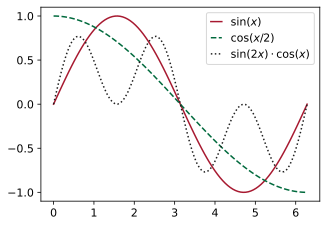

In [6]:
# | label: fig-sin
# | fig-cap: "Sinusoid & co."

import numpy as np
from matplotlib import pyplot

pyplot.plot(
    x := np.linspace(0, 2 * np.pi, 100), np.sin(x), label=r"$\sin(x)$"
)
pyplot.plot(x, np.cos(x / 2), label=r"$\cos(x/2)$")
pyplot.plot(
    x, np.sin(2 * x) * np.cos(x), label=r"$\sin(2x) \cdot \cos(x)$"
)
pyplot.legend();

## Using \techword{Pint} with \techword{Matplotlib} for automatic axis labelling


## Creating Sankey, Ishikawa and radar diagrams 


## Creating Gantt, pie and quadrant charts


## Creating \techword{UML} (class, sequence, activity) diagrams  


## Visualising networks with \techword{NetworkX}


## Rendering 3D scenes using \techword{PyVista}


### What is \techword{PyVista}?

> PyVista is the foundational Python library for 3D visualization and mesh analysis in scientific computing and engineering. PyVista plays the same role for 3D data that pandas plays for tabular data and xarray plays for labeled n-dimensional arrays.

> Quote from https://docs.pyvista.org/

When a thesis requires 3D graphics, tools like ParaView might not be enough. PyVista enables to prepare the simulation inside the code. This ensures automation and reproducibility in the notebook You create.

### Setting up example code

In [1]:
import numpy as np
import pyvista as pv

Example continuous data: smooth, scalar, background field

In [2]:
grid = pv.ImageData()
grid.dimensions = (30, 30, 1) # each dimension needs to be at least size 1
grid.spacing = (1.0, 1.0, 1.0)
grid.origin = (0.0, 0.0, 0.0)

x, y, z = np.mgrid[0:30, 0:30, 0:1]
cx, cy, cz = 15, 15, 15
field = np.exp(-((x-cx)**2 + (y-cy)**2) / (2 * cz**2))
grid.point_data["density"] = field.flatten(order="F")

Example discrete data: particles

In [3]:
n_particles = 40
rng = np.random.default_rng(42)

positions = rng.uniform(2, 28, size=(n_particles, 3))

masses = rng.uniform(0.5, 3.0, size=n_particles)
radii = rng. uniform(0.3, 1.2, size=n_particles)

particles = pv.PolyData(positions)
particles.point_data["mass"] = masses
particles.point_data["radius"] = radii

**Setting the jupyter backend**

For the plot to render correctly in pdf file the backend needs to be "static". However if you would like to move the scene around locally or show it in an html file you can switch to "trame"

For more information on how to use \techword{PyVista} in jupyter notebooks please check: https://tutorial.pyvista.org/tutorial/00_jupyter/index.html

In [8]:
pv.set_jupyter_backend("static")

Demonstration of \techword{PyVista} plotting

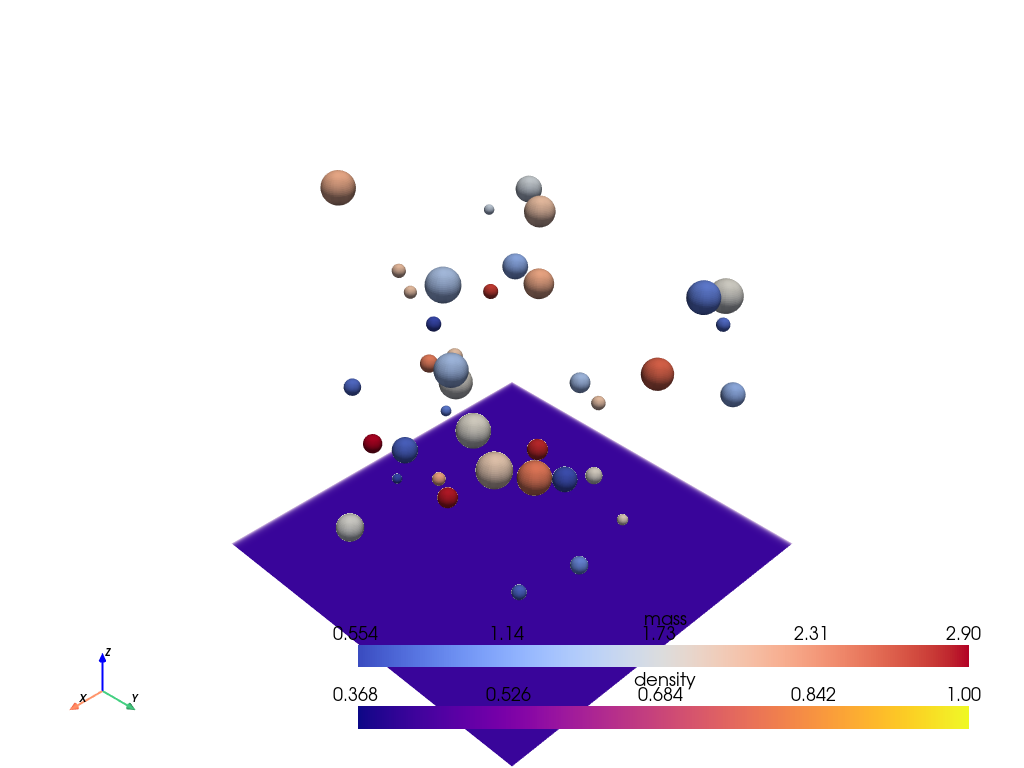

In [9]:
pl = pv.Plotter()

pl.add_volume(
    grid, #shape of the plot, data
    scalars="density", #based on what should the plot be colored
    cmap="plasma", #color choice
    opacity=1, # how invisible will the plot be on scale 0-1
)

sphere = pv.Sphere(radius=1) #note below
glyphs = particles.glyph(
    geom=sphere,
    scale="radius",
    orient=False,
)
glyphs.point_data["mass"] = np.repeat(masses, sphere.n_points)

pl.add_mesh(
    glyphs,
    scalars="mass",
    cmap="coolwarm",
    show_scalar_bar=True,
)
pl.show_axes()
pl.show()

Other available shapes for the "geom" argument:

- arrow
- box
- capsule
- cone
- cube
- dodecahedron
- ellipse
- tube
- text3d

For more check: https://docs.pyvista.org/api/utilities/geometric

### Additional information

While \techword{PyVista} is a great tool for reproducibility it has it's drawbacks. Unfortunately its documentation is well-prepared only for basic problems. Creating own simulation requires a lot of time to dig into the specification of functionalities, but the search tool can be very helpful.

\techword{PyVista} documentation (main page): https://docs.pyvista.org/

# Code availability and dissemination


## Code and content licensing and copyright considerations


## Persistent archival and \techword{DOI} assignment with \techword{Zenodo} and \techword{arXiv}


## Making your code publicly available as a package at \techword{PyPI.org}


## Version numbering and using \techword{git} metadata for package versions


## Making your docs available on \techword{GitHub Pages} or \techword{Read The Docs}


## Making your results reproducible on \techword{Colab} and \techword{mybinder.org}


# Final Touches

## Avoiding widows, orphans, and runts

[article in Polish Wikipedia](https://pl.wikipedia.org/wiki/B%C5%82%C4%99dy_typograficzne)

## Epigraphs

\epigraph{\it
  Program testing can be used to~show the presence of bugs, but~never to show their absence!
}{\citet{Dijkstra_1970}}

## Acknowledging the use of AI tools


## Creating a thesis defense slide deck with \techword{Quarto}
